In [1]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw"

classes = [
    "comedonal_closed",
    "comedonal_open",
    "inflammatory_acne",
    "acne_scars"
]

In [3]:
image_extensions = [".jpg", ".jpeg", ".png", ".webp"]
data = []
for class_name in classes:
    class_folder = RAW_DIR / class_name
    
    for image_path in class_folder.iterdir():
        if image_path.suffix.lower() in image_extensions:
            data.append({
                "filepath": image_path,
                "label": class_name,
                "extension": image_path.suffix.lower()
            })

df = pd.DataFrame(data)

df.head()

,filepath,label,extension
0,..\data\raw\comedonal_closed\come_001.png,comedonal_closed,.png
1,..\data\raw\comedonal_closed\come_002.png,comedonal_closed,.png
2,..\data\raw\comedonal_closed\come_003.png,comedonal_closed,.png
3,..\data\raw\comedonal_closed\come_004.png,comedonal_closed,.png
4,..\data\raw\comedonal_closed\come_005.png,comedonal_closed,.png


In [4]:
widths = []
heights = []
bad_files = []

for path in df["filepath"]:
    try:
        img = Image.open(path)
        widths.append(img.width)
        heights.append(img.height)
    except Exception as e:
        widths.append(None)
        heights.append(None)
        bad_files.append(path)

df["width"] = widths
df["height"] = heights

df.head()

,filepath,label,extension,width,height
0,..\data\raw\comedonal_closed\come_001.png,comedonal_closed,.png,382,240
1,..\data\raw\comedonal_closed\come_002.png,comedonal_closed,.png,421,245
2,..\data\raw\comedonal_closed\come_003.png,comedonal_closed,.png,376,609
3,..\data\raw\comedonal_closed\come_004.png,comedonal_closed,.png,340,347
4,..\data\raw\comedonal_closed\come_005.png,comedonal_closed,.png,845,612


In [5]:
df[["width", "height"]].describe()

,width,height
count,204.000000,204.000000
mean,542.357843,472.431373
std,359.675612,307.317137
min,124.000000,133.000000
25%,317.000000,296.500000
50%,442.000000,403.500000
75%,640.000000,538.000000
max,2730.000000,2532.000000


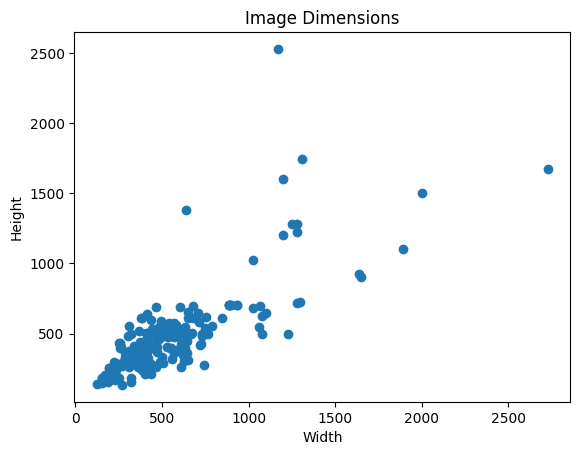

In [7]:
plt.scatter(df["width"], df["height"])
plt.title("Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

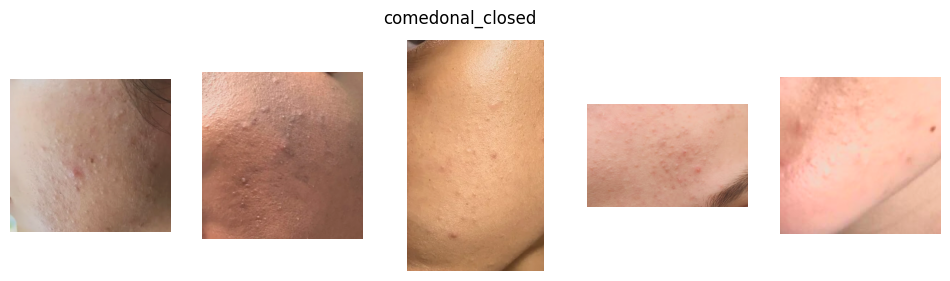

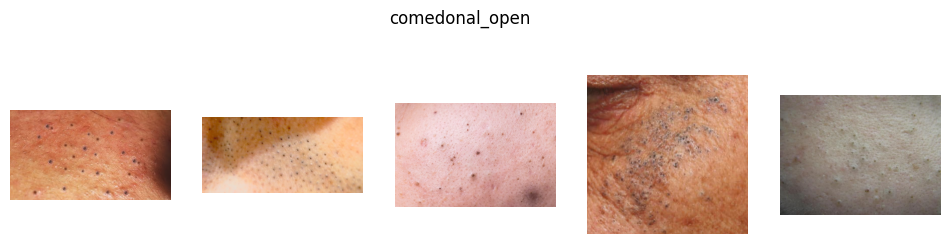

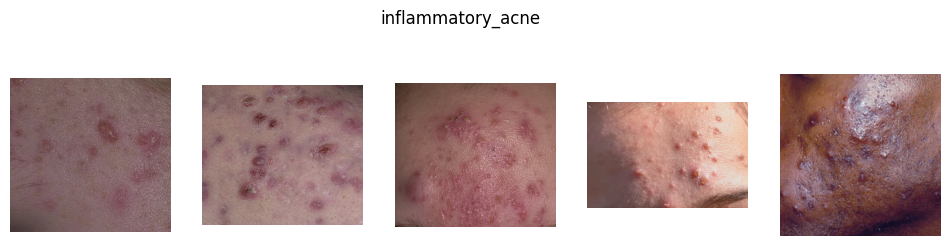

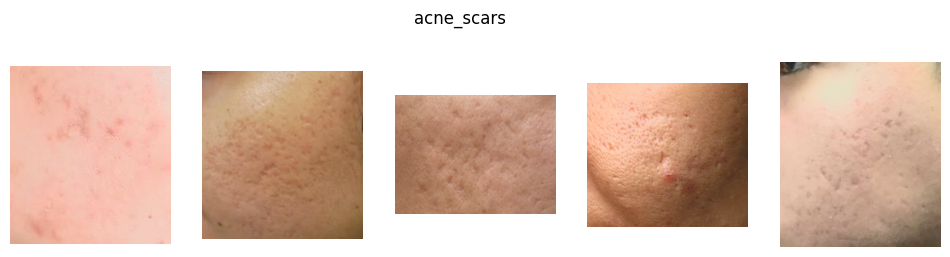

In [9]:
for class_name in classes:
    sample_paths = df[df["label"] == class_name]["filepath"].sample(
        min(5, len(df[df["label"] == class_name])),
        random_state=42
    )
    
    plt.figure(figsize=(12, 3))
    plt.suptitle(class_name)
    
    for i, path in enumerate(sample_paths):
        img = Image.open(path).convert("RGB")
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.show()

In [10]:
df["label"].value_counts()

label
comedonal_closed     52
comedonal_open       51
inflammatory_acne    51
acne_scars           50
Name: count, dtype: int64